In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

from gmdhpy import gmdh


In [61]:
df = pd.read_csv('AEP_hourly.csv', parse_dates=['Datetime'])
df.head()

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [62]:
df.shape

(121273, 2)

In [97]:
df = pd.read_csv('AEP_hourly.csv', parse_dates=['Datetime'])
df = df.sort_values('Datetime').reset_index(drop=True)
df_daily = df.set_index('Datetime').resample('D').mean().dropna()
last_date = df_daily.index.max()
start_date = last_date - pd.DateOffset(years=3)
df_daily = df_daily[df_daily.index >= start_date]
df_daily.shape

(1097, 1)

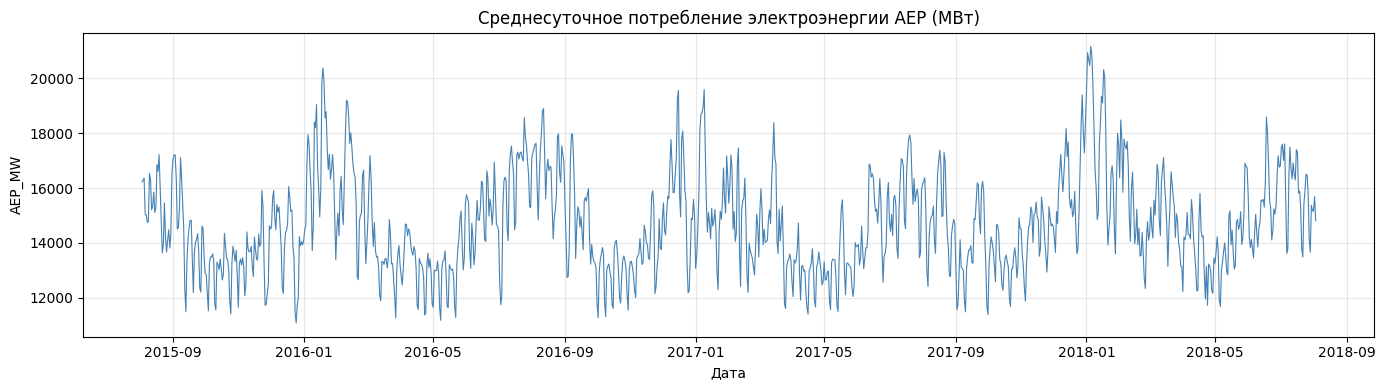

In [98]:
ts = pd.DataFrame() 
ts['AEP_MW'] = df_daily['AEP_MW']
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ts['AEP_MW'].index, ts['AEP_MW'].values, color='steelblue', linewidth=0.8)
ax.set_title('Среднесуточное потребление электроэнергии AEP (МВт)')
ax.set_xlabel('Дата'); ax.set_ylabel('AEP_MW')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

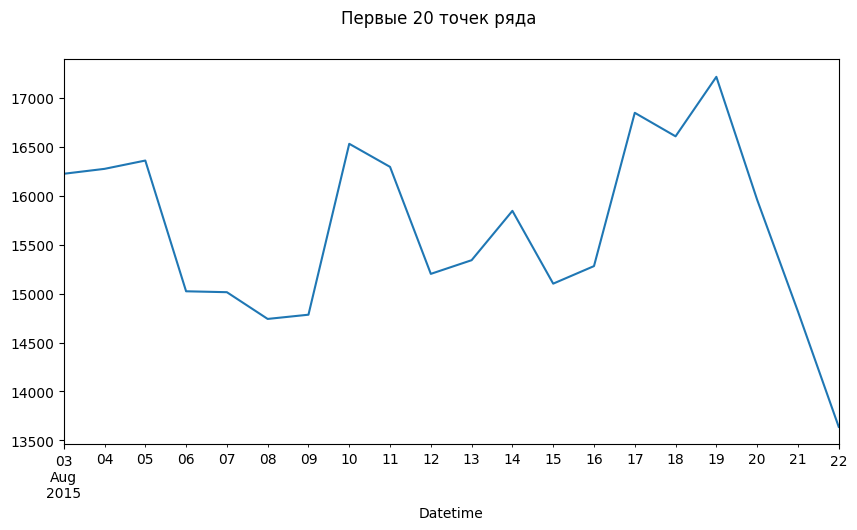

In [99]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Первые 20 точек ряда')
ts[:20].plot(ax=ax, legend=False)
plt.show()

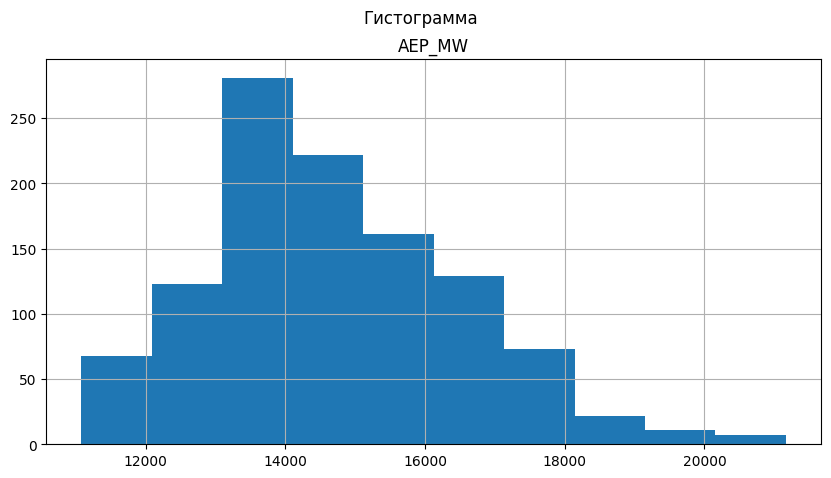

In [100]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Гистограмма')
ts.hist(ax=ax, legend=False)
plt.show()

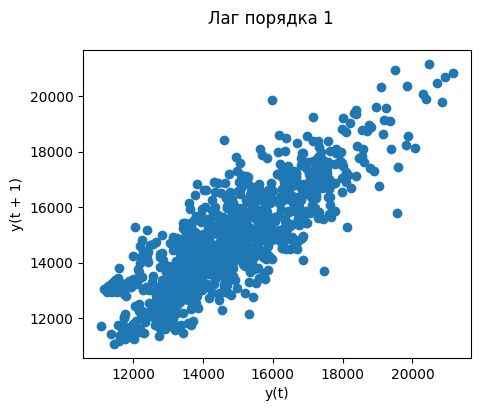

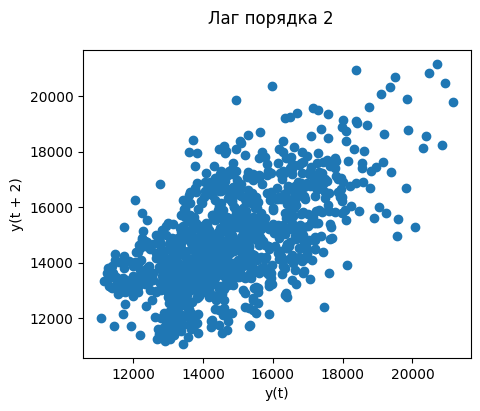

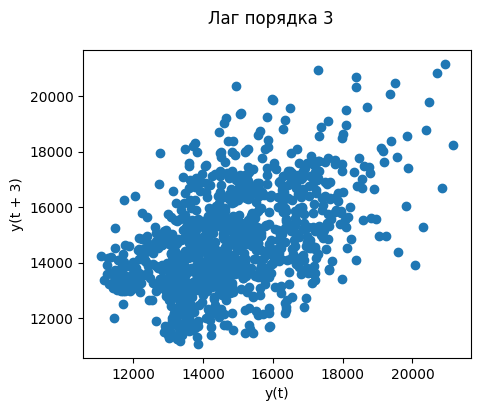

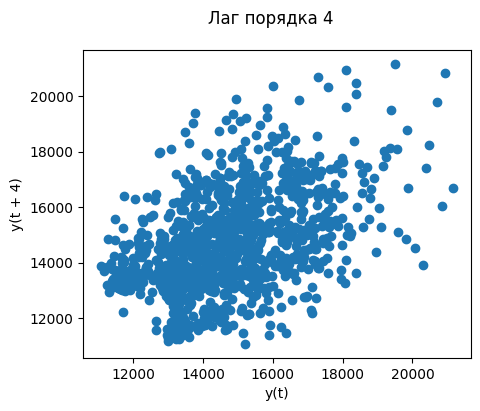

In [101]:
for i in range(1, 5):
    fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(5,4))
    fig.suptitle(f'Лаг порядка {i}')
    pd.plotting.lag_plot(ts, lag=i, ax=ax)
    plt.show()

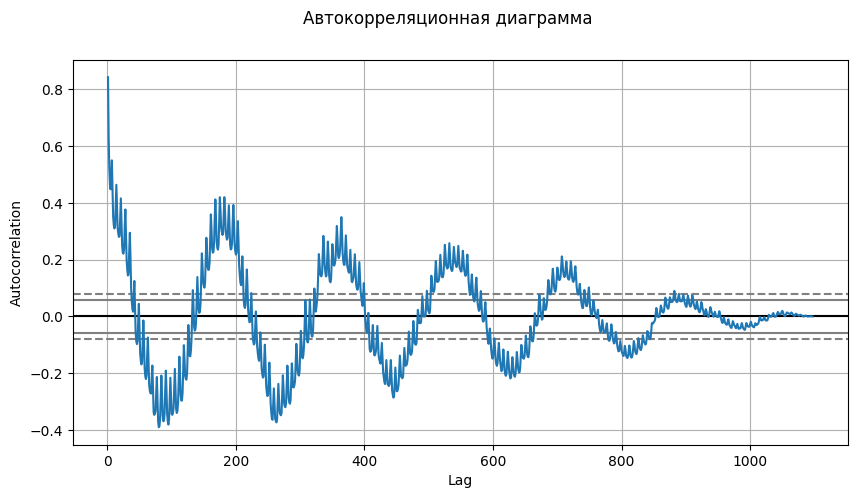

In [102]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Автокорреляционная диаграмма')
pd.plotting.autocorrelation_plot(ts, ax=ax)
plt.show()

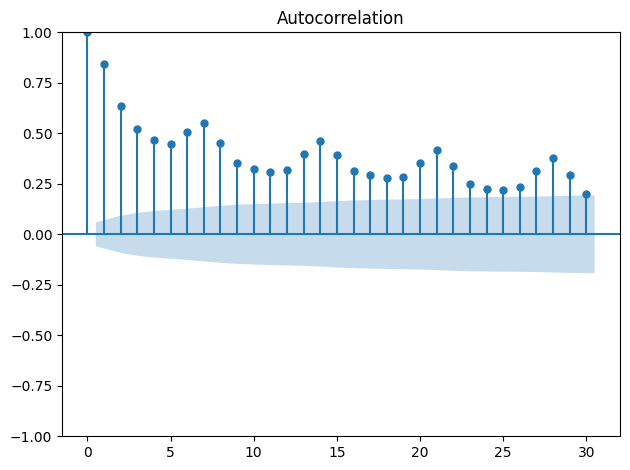

In [103]:
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(ts, lags=30)
plt.tight_layout()

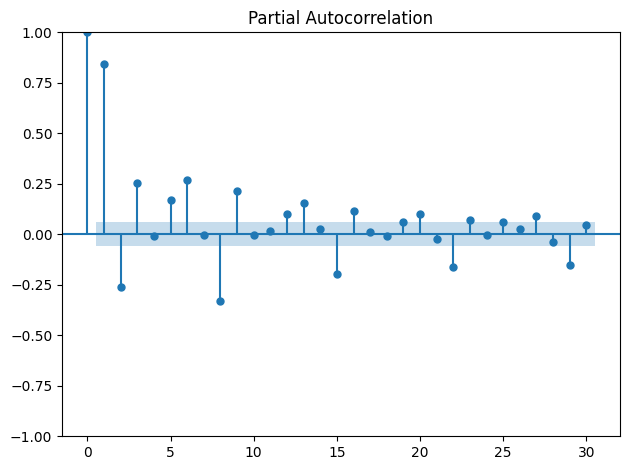

In [104]:
from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(ts, lags=30)
plt.tight_layout()

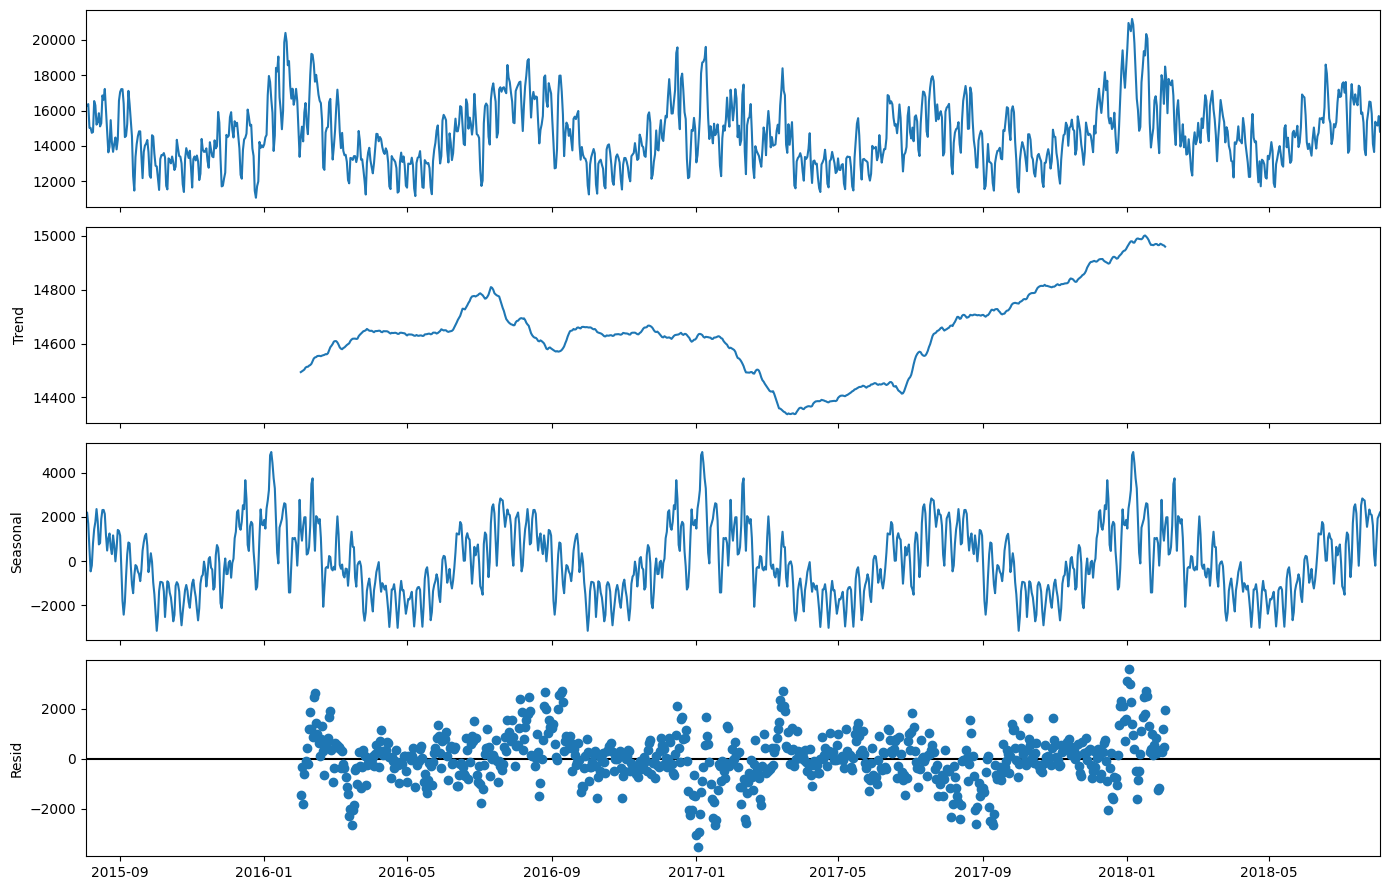

In [105]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(ts, model='additive', period=365)
fig = decomposition.plot()
fig.set_size_inches(14, 9)
plt.tight_layout(); plt.show()

In [106]:
adf = adfuller(ts)
print(f'ADF статистика: {adf[0]:.4f}')
print(f'p-value: {adf[1]:.4f}')
print(f'Ряд {"стационарен" if adf[1] < 0.05 else "нестационарен"} (на уровне 0.05)')

ADF статистика: -3.6944
p-value: 0.0042
Ряд стационарен (на уровне 0.05)


In [107]:

ts2 = ts.copy()

ts2['SMA_10'] = ts2['AEP_MW'].rolling(window=10, min_periods=1).mean()
ts2['SMA_20'] = ts2['AEP_MW'].rolling(window=20, min_periods=1).mean()

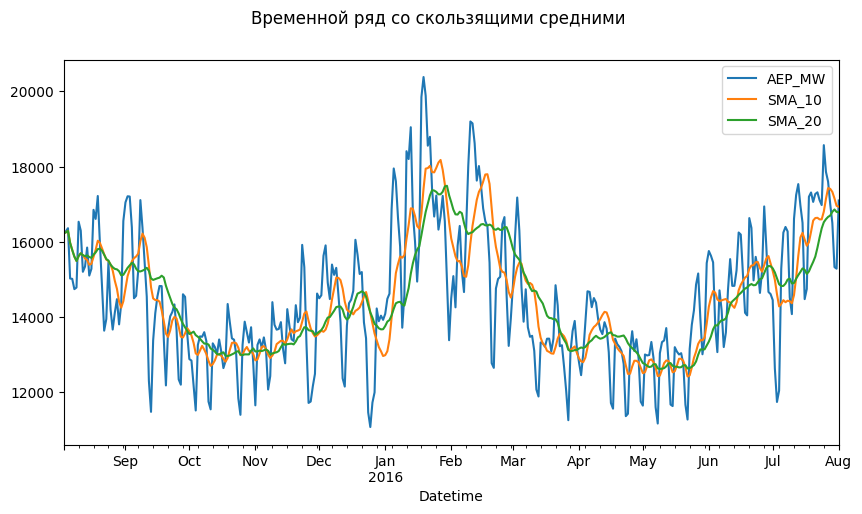

In [108]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(10,5))
fig.suptitle('Временной ряд со скользящими средними')
ts2[:365].plot(ax=ax, legend=True)
plt.show()

In [109]:
xnum = list(range(ts.shape[0]))
Y = ts.values
train_size = int(len(Y) * 0.8)
xnum_train, xnum_test = xnum[0:train_size], xnum[train_size:]
train, test = Y[0:train_size], Y[train_size:]
history_arima = [x for x in train]
history_es = [x for x in train]

In [110]:
from statsmodels.tsa.arima.model import ARIMA
# Параметры модели (p,d,q) 
arima_order = (6,1,0)
# Формирование предсказаний
predictions_arima = list()
for t in range(len(test)):
    model_arima = ARIMA(history_arima, order=arima_order)
    model_arima_fit = model_arima.fit()
    yhat_arima = model_arima_fit.forecast()[0]
    predictions_arima.append(yhat_arima)
    history_arima.append(test[t])
# Вычисление метрики MSE
error_arima = mean_squared_error(test, predictions_arima)

In [111]:
ts2['predictions_ARIMA'] = (train_size * [np.nan]) + list(predictions_arima)

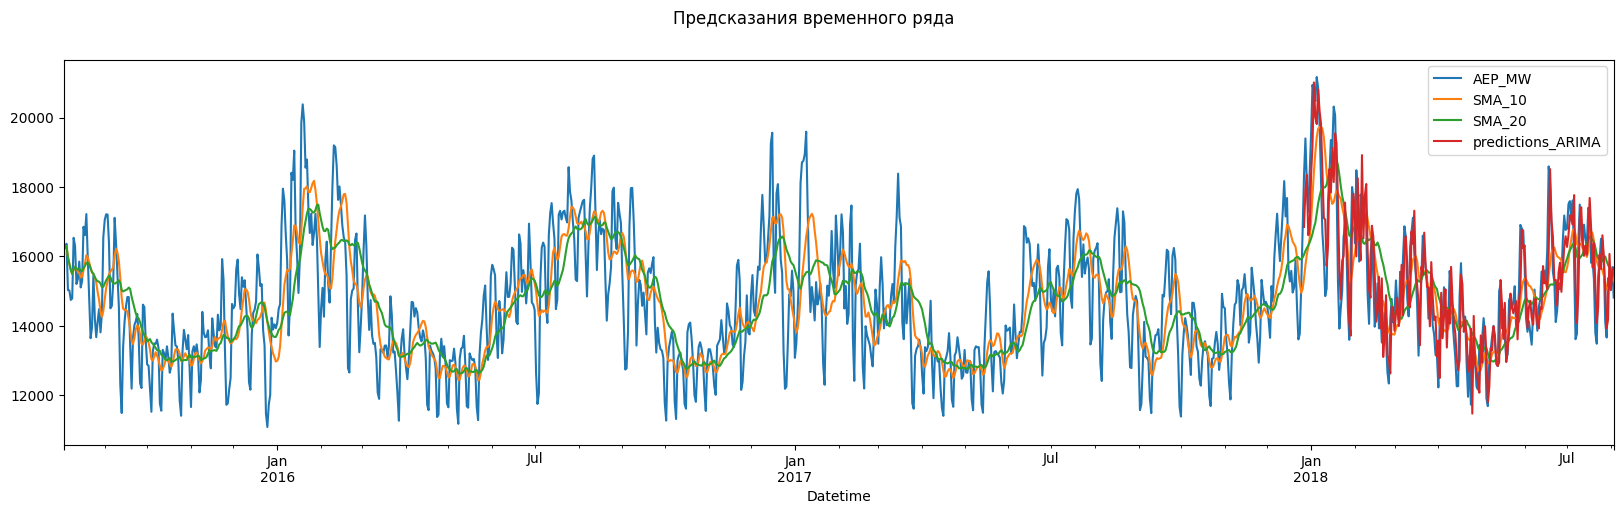

In [112]:
fig, ax = plt.subplots(1, 1, sharex='col', sharey='row', figsize=(20,5))
fig.suptitle('Предсказания временного ряда')
ts2.plot(ax=ax, legend=True)
plt.show()

/Users/anlimka/Desktop/МЛ/Labolatornye_ML/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0   263.65      1.18531e+67       99      1.10787e+08              N/A     38.45s
   1   153.28      3.01049e+17       20      7.87787e+07              N/A     14.98s
   2    95.75      7.43497e+14      155      2.63993e+07              N/A     11.18s
   3    81.19      9.51868e+10      198      4.04528e+06              N/A     10.15s
   4   150.08       1.8597e+10      121      3.86292e+06              N/A     13.78s
   5   179.51       3.0729e+12      160      3.79183e+06              N/A     15.11s
   6   181.31      1.02367e+15      164      3.36758e+06              N/A     14.93s
   7   175.29      3.04637e+12      157      3.35379e+06              N/A     14.78s
   8   157.88      2.07729e+14      172      3.28404e+06              N/A  

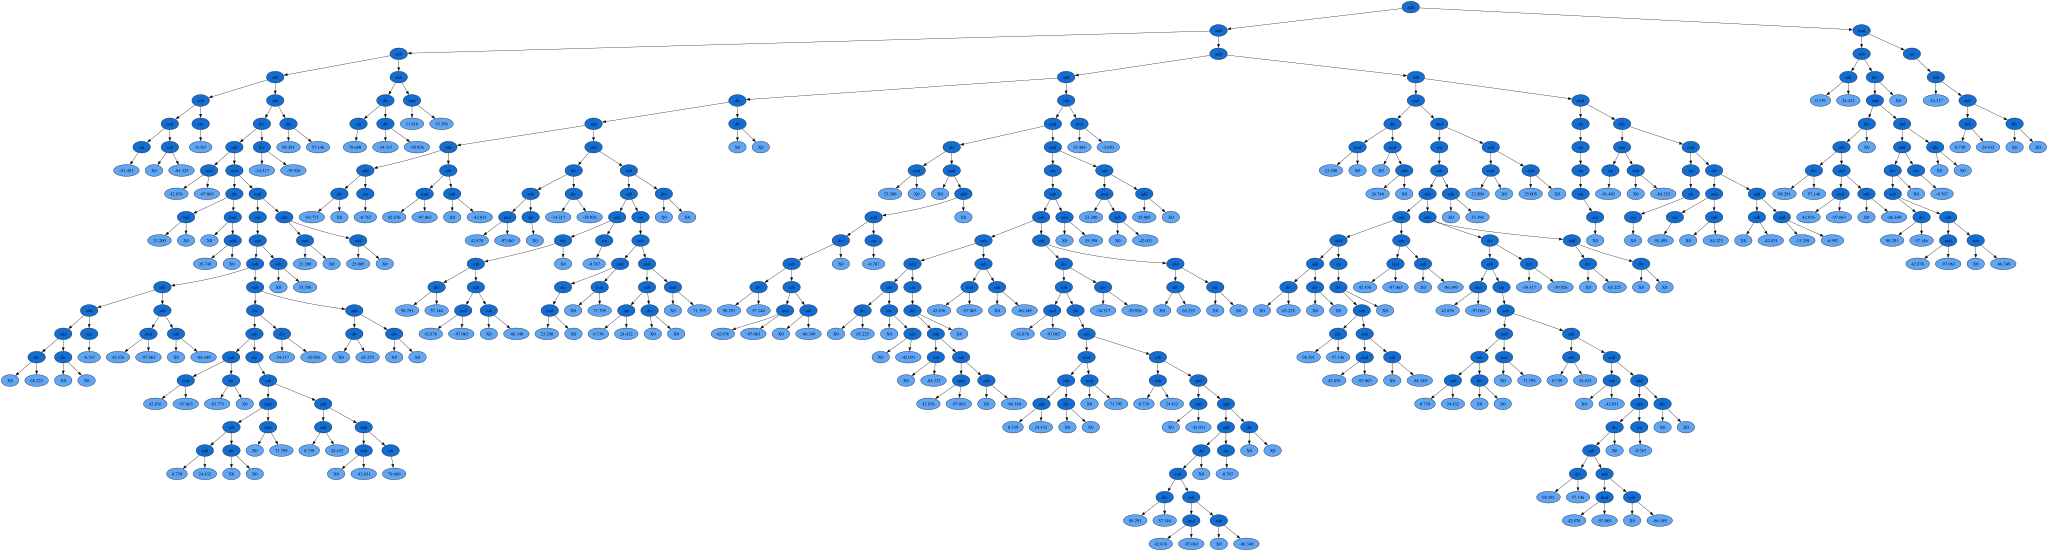

In [ ]:
from gplearn.genetic import SymbolicRegressor
function_set = ['add', 'sub', 'mul', 'div', 'sin']
est_gp = SymbolicRegressor(population_size=500, metric='mse',
                               generations=70, stopping_criteria=0.01,
                               init_depth=(4, 10), verbose=1, function_set=function_set,
                               const_range=(-100, 100), random_state=0)
est_gp.fit(np.array(xnum_train).reshape(-1, 1), train.reshape(-1, 1))
print(est_gp._program)
import graphviz
dot_data = est_gp._program.export_graphviz()
graph = graphviz.Source(dot_data)
graph